# Requirement Report Generation 

Requirements related to High Bypass Turbo Fan Component


### Model-Specific Code (Do Not Modify)

This section contains code that is specific to the system model. It is updated only when the model is changed and should not require user modifications under normal circumstances.

If a new model is introduced, ensure this section is reviewed and updated as needed.


In [1]:
#!pip install --upgrade git+https://github.com/tkSDISW/Capella_Tools 
import capellambse.decl

from capella_tools import capellambse_helper


from IPython import display as diag_display
resources = {
    "HBTurboFan": "HBTurbFan/High Bypass Turbo Fan",
}
path_to_model = "../High Bypass Turbo Fan.aird"
model = capellambse.MelodyModel(path_to_model, resources=resources)





Load Embedding to locate the object by name.


In [2]:

from capella_tools  import capella_embeddings_manager

# Generate embeddings for all objects
model_embedding_manager = capella_embeddings_manager.EmbeddingManager()

embedding_file = "embeddings.json" 
model_embedding_manager.set_files( path_to_model , embedding_file)

model_embedding_manager.create_model_embeddings(model)

✅ EmbeddingManager initialized
🔐 API Key: Loaded from secrets
🌐 Base URL: Default
🤖 Model: gpt-4o
Loading embeddings
embeddings loaded.


Search for the component. 


In [3]:

selected_objects = model_embedding_manager.query_and_select_top_objects("High Bypass Turbo Fan Logical Component", top_n=1)



This is a list of ranked Objects Based on Query:
Index: 0, Name: High Bypass Turbo Fan, Similarity: 0.88, Type: LogicalComponent, Phase: Logical Architecture LA, Source: , Target: 



 📝 Generate Structured Input File 
.

In [4]:
#Workflow
from capella_tools import capellambse_yaml_manager
yaml_handler = capellambse_yaml_manager.CapellaYAMLHandler()
   
#Generate YAML for the logical component and append to the file
for object in  selected_objects : 
    yaml_handler.generate_yaml(model.by_uuid(object["uuid"]))  



#yaml_handler.display()
yaml_handler.generate_yaml_referenced_objects()
#yaml_handler.display()

yaml_handler.write_output_file()


## 🖼️ Generate Contextual Diagram




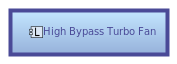



**Presentation of saved diagram:**
../Images/[LAB] High Bypass Turbo Fan - Context .jpg

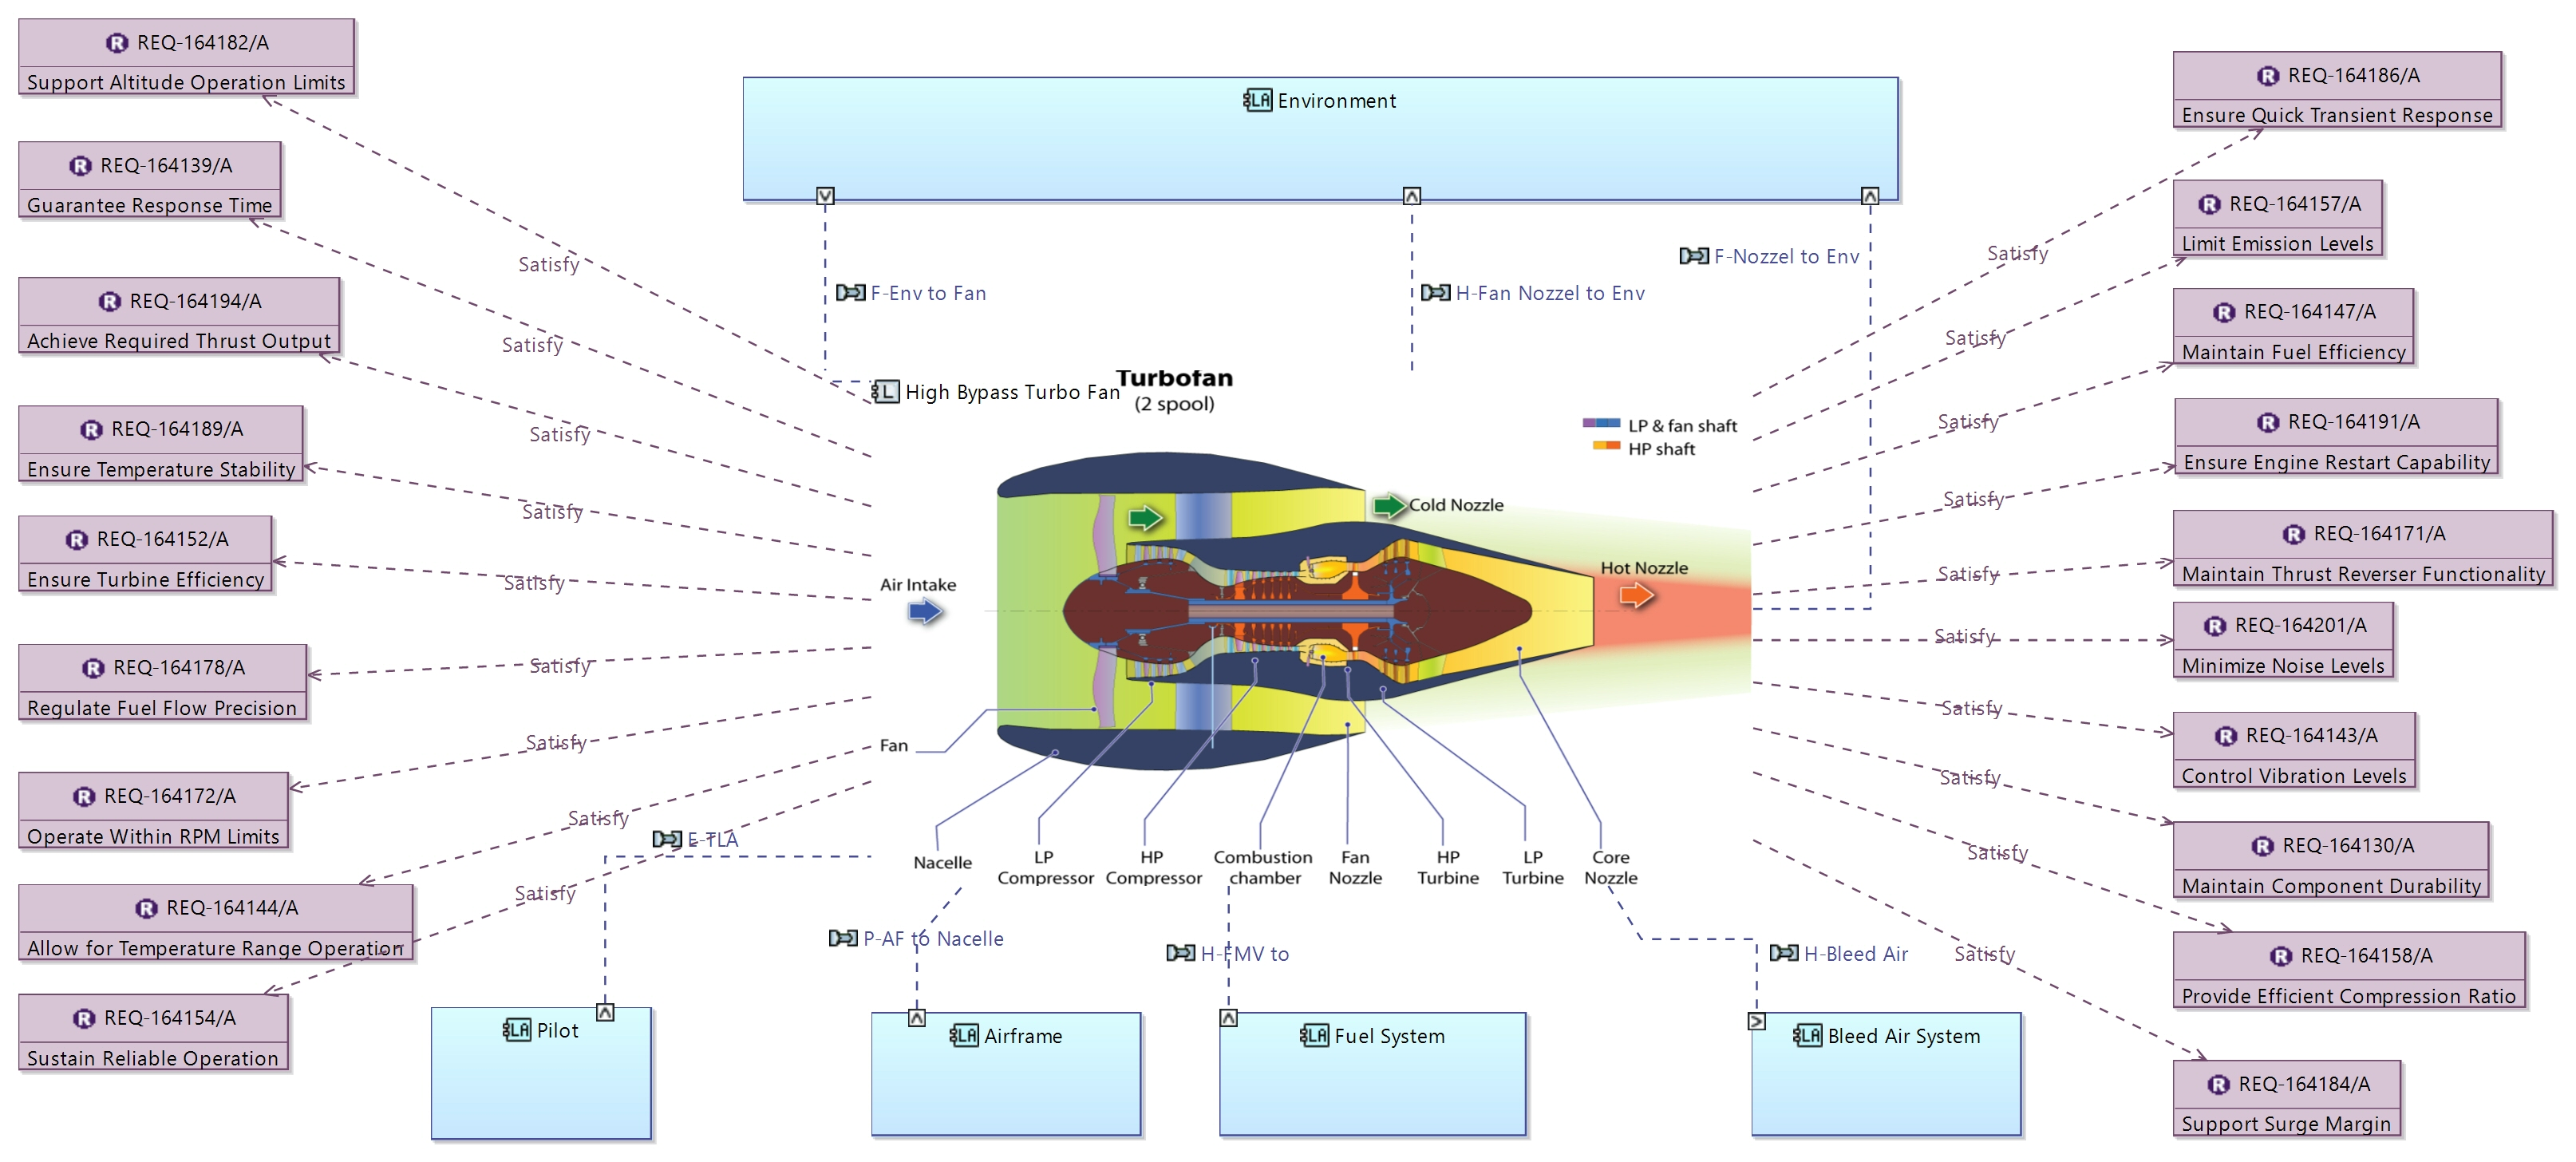

In [5]:
from capella_tools import capellambse_helper
from IPython import display as diag_display
from IPython.display import Markdown
for object in  selected_objects : 
    #print(object)
    if object["type"] == "Diagram" :
        diagram = model.by_uuid(object["uuid"])
        #display(diagram)
    else:
        obj = model.by_uuid(object["uuid"])
        capellambse_helper.display_context_diagram(obj)


diagram_file ="../Images/[LAB] High Bypass Turbo Fan - Context .jpg"
display(Markdown(f"\n\n**Presentation of saved diagram:**\n{diagram_file}"))
display(diag_display.Image(filename=diagram_file) ) # Explicitly display the image

In [6]:
prompt = """
Please analyze the yaml file and display the result as .html and specifically provide insights on:
1. THe Component and its relations to Actors.
2. All Requirement related to the component 
    The relationship used to relate to the component.
    A report on all the requirement properties.

"""


In [7]:
import os
from openai import OpenAI
from IPython.core.display import HTML
from IPython.display import display, clear_output, Markdown
from capella_tools  import Open_AI_RAG_manager
  


# Step 1: Get YAML content
yaml_content = yaml_handler.get_yaml_content()

# Step 2: Invoke ChatGPT for analysis
analyzer = Open_AI_RAG_manager.ChatGPTAnalyzer(yaml_content)
analyzer.initial_prompt(prompt)
chatgpt_response = analyzer.get_response()


✅ ChatGPTAnalyzer initialized
🔐 API Key: Loaded from secrets
🌐 Base URL: Default
🤖 Model: gpt-4o


**Your prompt:** 
Please analyze the yaml file and display the result as .html and specifically provide insights on:
1. THe Component and its relations to Actors.
2. All Requirement related to the component 
    The relationship used to relate to the component.
    A report on all the requirement properties.

 Format the response in .html format.

Component,Actor,Type of Relationship
High Bypass Turbo Fan,Pilot,Throttle Input via Throttle Lever Angle (Component Exchange)
Requirement Name,Description,Relationship Type
Minimize Noise Levels,The engine shall limit noise emissions to no more than [F] dB during takeoff and landing phases.,Satisfy
Operate Within RPM Limits,The fan and compressor shall operate at speeds not greater than [Z] RPM under maximum thrust settings.,Satisfy
Ensure Quick Transient Response,The engine shall achieve required thrust transitions within [R] seconds to accommodate rapid changes in flight demand.,Satisfy
Support Surge Margin,The compressor shall maintain a surge margin of no less than [P]% to ensure pressure stability.,Satisfy
Control Vibration Levels,The engine shall operate with vibration levels not exceeding [G] mm/s to ensure structural integrity.,Satisfy
Provide Efficient Compression Ratio,The compressor shall maintain a compression ratio of [B]:1 to ensure efficient airflow management.,Satisfy
Limit Emission Levels,The engine shall not produce emissions exceeding [H] grams per kilowatt-hour to meet environmental standards.,Satisfy
Allow for Temperature Range Operation,The engine shall function effectively in ambient temperatures ranging from [N]°C to [O]°C.,Satisfy


**Token Usage Info:**

Tokens used: prompt=104040, completion=2292, total=106332

## ⚙️ Execute Followup Prompts

### Purpose
This cell executes the **follow up prompts** defined for analyzing the model. These prompts can be added by the note book user in addition to the default prompts

### What This Cell Does
- Use the structured input file (e.g., `capella_model.yaml`).
- Excutes the prompt defined in the cell.
- Outputs the results directly in the notebook.

### 🛠️ Instructions
1. Ensure the `capella_model.yaml` file is generated and up-to-date.
2. Run this cell to execute the default prompts.
3. Review the output to verify the accuracy and relevance of the analysis.

> 💡 **Tip:** Modify the promt to your needs.

In [8]:
#analyzer.follow_up_prompt("Review the Sensors and actuators associated with the Stage 3 diagram and recommend any that may be missing..")
#chatgpt_response = analyzer.get_response()




In [9]:
print("Done")

Done


# 